In [1]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(1520)  # For reproducibility

---

# **Exercise 1**

# Question 1: 

# ***DFJ Formulation of TSP :***

The DFJ (Dantzig–Fulkerson–Johnson) formulation ensures a valid TSP tour because of two key constraints:

### ***Objective Function :***
Minimize the total distance of the tour:
$$
\min \sum_{e \in E} c_e x_e
$$
(Where $c_e$ is the cost/distance of edge $e$)

### ***Subject to:***


### ***(a) Degree constraints :***
$$
\sum_{e \in \delta(i)} x_e = 2 \quad \forall i \in V
$$
* Each city has exactly ***2 edges*** connected
* So every city is ***entered once and exited once***
* This ensures ***cycles are formed***.

### ***(b) Subtour elimination constraints :***
$$
\sum_{e \in \delta(S)} x_e \geq 2 \quad \forall S \subset V
$$
* Prevents formation of ***smaller disconnected cycles (subtours)***
* Forces the solution to be ***one single cycle covering all cities***

### ***(c) Binary constraints :***
$$
x_e \in \{0, 1\}
$$
* Either an edge is selected or not

Where:
* $\delta(i) = \{e ∈ E \ \text{such that edge e is incident on vertex i}\}$
* $\delta(S) = \{e ∈ E \ \text{such that edge e is incident on exactly one vertex in S}\}$
* $n$ is the total number of cities.

### ***Why it gives feasible tours ?***
The degree constraints ensure that each city has exactly two incident edges, forming cycles, while the subtour elimination constraints prevent multiple disconnected cycles by enforcing connectivity across all subsets. Together with binary constraints, this guarantees a single Hamiltonian cycle visiting each city exactly once.

# Question 2: 

In [3]:
cities = ["B", "K", "KGP", "M", "D", "G", "R"]

dist = {
    ("B","K"):1289, ("B","KGP"):1753, ("B","M"):1364, ("B","D"):1432, ("B","G"):2586, ("B","R"):1594,
    ("K","KGP"):1167, ("K","M"):1868, ("K","D"):495, ("K","G"):1432, ("K","R"):630,
    ("KGP","M"):1562, ("KGP","D"):1567, ("KGP","G"):1057, ("KGP","R"):1703,
    ("M","D"):2207, ("M","G"):2643, ("M","R"):2343,
    ("D","G"):1891, ("D","R"):212,
    ("G","R"):2055
}

# Make symmetric
for (i,j) in list(dist.keys()):
    dist[(j,i)] = dist[(i,j)]

# Undirected edges
edges = [(i,j) for i in cities for j in cities if i<j]

In [4]:
model = pulp.LpProblem("TSP", pulp.LpMinimize)
x = pulp.LpVariable.dicts("x", edges, 0, 1, pulp.LpBinary)

# Objective
model += pulp.lpSum(dist[(i,j)]*x[(i,j)] for (i,j) in edges)

# Degree constraints
for c in cities:
    model += pulp.lpSum(x[(min(c,j), max(c,j))] for j in cities if j!=c) == 2

In [5]:
def find_subtours(selected_edges):
    graph = {c: [] for c in cities}
    for i,j in selected_edges:
        graph[i].append(j)
        graph[j].append(i)

    visited = set()
    subtours = []

    for c in cities:
        if c not in visited:
            stack = [c]
            comp = []
            while stack:
                node = stack.pop()
                if node not in visited:
                    visited.add(node)
                    comp.append(node)
                    stack.extend(graph[node])
            
            subtours.append(comp)

    return subtours

In [6]:
# Cutting Plane Method
while True:
    model.solve(pulp.PULP_CBC_CMD(msg=0))
    selected_edges = [(i,j) for (i,j) in edges if pulp.value(x[(i,j)])>0.5]
    subtours = find_subtours(selected_edges)

    if len(subtours) == 1:
        break

    for tour in subtours:
        if len(tour) < len(cities):
            model += pulp.lpSum(x[(i,j)] for i in tour for j in tour if i<j) <= len(tour)-1

In [7]:
def build_tour(edges):
    graph = {c: [] for c in cities}

    for i,j in edges:
        graph[i].append(j)
        graph[j].append(i)

    tour = []
    current = cities[0]
    prev = None

    while True:
        tour.append(current)
        nxt = graph[current][0] if graph[current][0] != prev else graph[current][1]
        prev, current = current, nxt

        if current == tour[0]:
            tour.append(current)
            break

    return tour

In [8]:
# Forward tour
tour = build_tour(selected_edges)
print("Forward Optimal tour:")
print(" → ".join(tour))

# Reverse tour
reverse_tour = tour[::-1]
print("\nReverse Optimal tour:")
print(" → ".join(reverse_tour))

print("\nTotal cost:", pulp.value(model.objective))

Forward Optimal tour:
B → M → KGP → G → K → R → D → B

Reverse Optimal tour:
B → D → R → K → G → KGP → M → B

Total cost: 7689.0


# Question 3: 

The extreme points of the ***TSP polytope*** correspond to all feasible tours. For $n$ cities, the number of distinct tours is $(n - 1)! / 2$, since a tour and its reverse are considered the same.For $n = 7$, the number of extreme points is:
$$
\frac{6!}{2} = \boxed{360}
$$

# Question 4: 

In [9]:
def is_extreme_point(x_sol):
    """
    x_sol: dictionary {(i,j): 0/1}
    """

    # Step 1: Degree check
    degree = {c: 0 for c in cities}
    selected_edges = []

    for (i,j), val in x_sol.items():
        if val == 1:
            degree[i] += 1
            degree[j] += 1
            selected_edges.append((i,j))

    for c in cities:
        if degree[c] != 2:
            return "not an extreme point"

    # Step 2: Connectivity check
    graph = {c: [] for c in cities}
    for i,j in selected_edges:
        graph[i].append(j)
        graph[j].append(i)

    visited = set()
    stack = [cities[0]]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])

    if len(visited) == len(cities):
        return "extreme point"
    else:
        return "not an extreme point"

In [10]:
# Using Optimal Solution
x_example = {
    ("B","M"):1, ("B","D"):1,
    ("K","R"):1, ("KGP","M"):1,
    ("D","R"):1, ("G","K"):1,
    ("G","KGP"):1
}

print(is_extreme_point(x_example))

extreme point


---

# **Exercise 2**

# Question 1: 

# ***Description of Travelling Salesman Problem (TSP)***

The ***Travelling Salesman Problem (TSP)*** is a combinatorial optimization problem where:

* A salesman must visit ***each city exactly once***
* Return to the ***starting city***
* Minimize the ***total travel distance***

Formally:

* Input: Set of cities + distance matrix
* Output: Optimal tour (permutation of cities) with minimum cost

# Question 2: 

In [11]:
tsp11 = pd.read_csv("TSP11.csv", index_col=0)
tsp11.index = tsp11.index.str.replace("City_", "")
tsp11.columns = tsp11.columns.str.replace("City_", "")
tsp11

,1,2,3,4,5,6,7,8,9,10,11
1,0,485,398,320,156,121,238,70,152,171,264
2,485,0,422,149,409,201,180,199,358,307,393
3,398,422,0,241,493,326,210,363,71,302,285
4,320,149,241,0,237,320,239,495,224,495,100
5,156,409,493,237,0,356,184,70,378,216,323
6,121,201,326,320,356,0,395,102,435,389,141
7,238,180,210,239,184,395,0,130,469,99,409
8,70,199,363,495,70,102,130,0,451,267,93
9,152,358,71,224,378,435,469,451,0,239,345
10,171,307,302,495,216,389,99,267,239,0,237


# Question 3: 

***The pseudo-code is given in the question. Nothing to report here.***

# Question 4: 

In [12]:
def cost(tour, Adjacency_Matrix):
    total_cost = 0
    n = len(tour)
    for i in range(n-1):
        total_cost += Adjacency_Matrix[tour[i]][tour[i+1]]
    # return to start
    total_cost += Adjacency_Matrix[tour[-1]][tour[0]]
    
    return total_cost

# Question 5: 

In [13]:
def neighbour(tour):
    new_tour = tour.copy()
    n = len(tour)
    i = np.random.randint(0,n-1)
    j = (i+1) % n   # consecutive swap
    
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    
    return new_tour

# Question 6: 

# ***Acceptance Probability :***

The probability $P$ of accepting a move that increases the cost is calculated as:
$$P = e^{-(c_{new} - c_{old}) / T_k}$$

* $c_{new} - c_{old}$: The difference in "cost" or "energy." If this is positive, the new move is worse.
* $T_k$: The current "temperature" of the system.

### ***Description :***
In standard optimization, you only move to a better solution (greedy approach). However, this often leads to getting stuck in a local minimum—a valley that looks like the best spot but isn't the true global lowest point. By allowing a probability $P$ where $0 < P < 1$, the algorithm occasionally accepts a worse move. This "jump" helps the algorithm climb out of small valleys so it can find the global minimum.

The temperature controls the algorithm's willingness to take risks. 
* ***High Temperature (Start) :*** When $T_k$ is high, the exponent stays close to zero, making $P$ closer to 1. The algorithm explores the landscape wildly, accepting almost any move.

* ***Low Temperature (End) :*** As $T_k$ decreases, the denominator gets smaller, causing the probability $P$ to drop toward zero.

* ***The Result :*** The algorithm becomes "greedier." It stops taking risks and starts settling into the best possible hole it has found, fine-tuning the final solution.

### ***Implementation :***

In [14]:
def accept_prob(old_cost, new_cost, T):
    if new_cost < old_cost:
        return 1.0
    else:
        return np.exp(-(new_cost-old_cost)/T)

### ***Behavior Explanation :***

***(1) When the new cost is worse ($c_{new} > c_{old}$)***

The difference $c_{new} - c_{old} > 0$, so:
$$
P = e^{-\text{positive} / T_k} \implies 0 < P < 1
$$

**Behavior :**
* The new (worse) solution is accepted with some probability
* If the cost difference is small, probability is high
* If the cost difference is large, probability is low

**Interpretation :**
* Allows ***uphill moves*** (accepting worse solutions)
* Helps the algorithm:
    - Escape local minima
    - Explore more of the solution space

***(2) When temperature decreases***

As $T_k$ becomes smaller:
$$
P = e^{-\frac{(c_{new} - c_{old})}{T_k}} \rightarrow 0
$$

**Behavior :**
* Probability of accepting worse solutions ***decreases***
* Algorithm becomes more ***selective***

**Interpretation :**
* At high temperature:
    - More randomness
    - More exploration
* At low temperature:
    - Almost no bad moves accepted
    - Algorithm behaves like ***greedy optimization***

# Question 7: 

In [15]:
def geometric_cooling(T, alpha):
    return alpha * T

In [16]:
def simulated_annealing(Adjacency_Matrix, cooling_schedule, T0, alpha, max_iter):
    # initial solution
    current = list(Adjacency_Matrix.index)
    np.random.shuffle(current)
    
    best = current.copy()
    current_cost = cost(current, Adjacency_Matrix)
    best_cost = current_cost
    
    T = T0
    costs = []
    for _ in range(max_iter):
        new = neighbour(current)
        new_cost = cost(new, Adjacency_Matrix)
        
        if new_cost < current_cost:
            current = new
            current_cost = new_cost
        else:
            prob = np.exp(-(new_cost-current_cost)/T)
            if np.random.random() < prob:
                current = new
                current_cost = new_cost
        
        if current_cost < best_cost:
            best = current
            best_cost = current_cost
        
        costs.append(best_cost)
        T = cooling_schedule(T, alpha)
    
    best.append(best[0])  # Return to start
    
    return best, best_cost, costs

# Question 8: 

In [17]:
def run_experiment(Adjacency_Matrix, cooling_schedule, T0, alpha=0.95, max_iter=100):   # given α >= 0.80
    best_tour, best_cost, costs = simulated_annealing(Adjacency_Matrix, cooling_schedule, T0, alpha, max_iter)
    
    print(f"\nRunning with T0 = {T0}\n")
    # Forward tour
    print("Forward Optimal tour:")
    print(" → ".join(best_tour))

    # Reverse tour
    reverse_tour = best_tour[::-1]
    print("\nReverse Optimal tour:")
    print(" → ".join(reverse_tour))

    print("\nTotal cost:", best_cost)

    plt.figure(figsize=(14,4.5))
    sns.lineplot(costs, marker="s", color="purple", markerfacecolor="green", label="Cost", linewidth=1.5, markersize=6)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"Cost vs Iteration [$T_0$ = {T0}]\n(25M1520)")
    plt.show()
    print("---"*50)


Running with T0 = 1

Forward Optimal tour:
6 → 8 → 1 → 10 → 11 → 4 → 3 → 7 → 5 → 9 → 2 → 6

Reverse Optimal tour:
6 → 2 → 9 → 5 → 7 → 3 → 4 → 11 → 10 → 1 → 8 → 6

Total cost: 2252


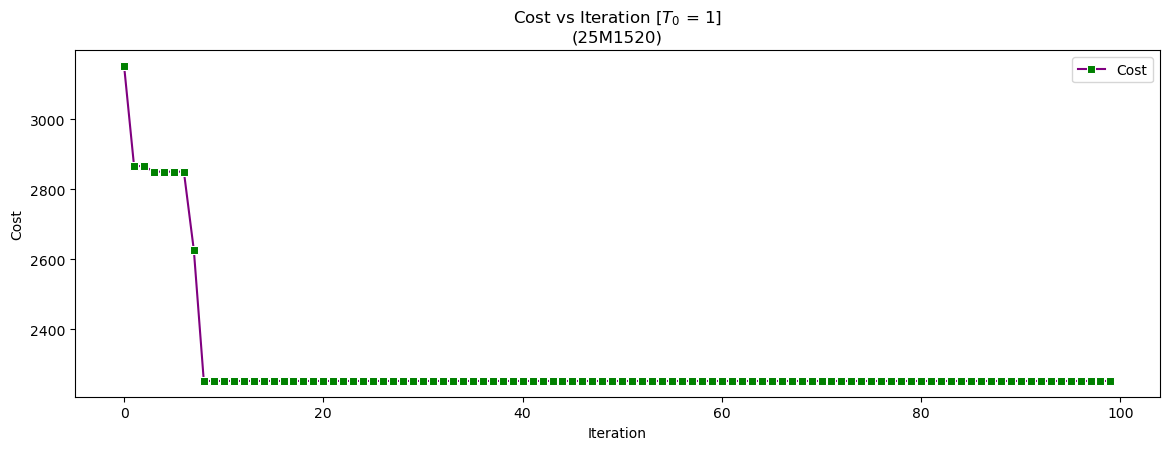

------------------------------------------------------------------------------------------------------------------------------------------------------


In [18]:
run_experiment(Adjacency_Matrix=tsp11, cooling_schedule=geometric_cooling, T0=1)

### ***Explanation :***

* Initially, the cost fluctuates a lot due to ***high temperature*** (more exploration).

* As iterations increase, the cost gradually ***decreases and stabilizes***.

* The algorithm ***converges*** to a near-optimal solution.

* ***Higher $T_0$*** : better exploration but slower convergence.

* ***Lower $T_0$*** : faster convergence but may get stuck in ***local minima***.


Running with T0 = 10

Forward Optimal tour:
2 → 9 → 10 → 5 → 4 → 6 → 3 → 7 → 1 → 11 → 8 → 2

Reverse Optimal tour:
2 → 8 → 11 → 1 → 7 → 3 → 6 → 4 → 5 → 10 → 9 → 2

Total cost: 2700


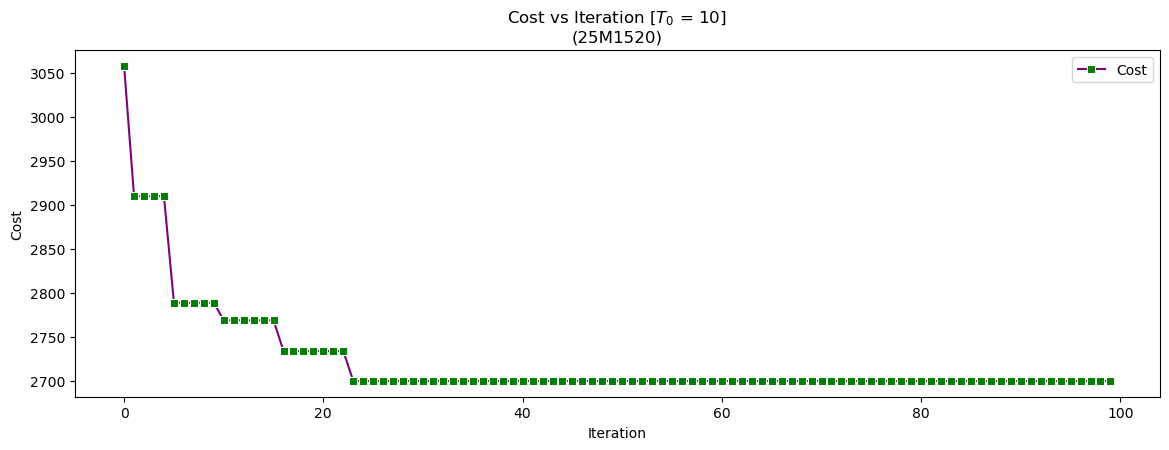

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 25

Forward Optimal tour:
10 → 8 → 6 → 2 → 9 → 3 → 4 → 11 → 1 → 5 → 7 → 10

Reverse Optimal tour:
10 → 7 → 5 → 1 → 11 → 4 → 3 → 9 → 2 → 6 → 8 → 10

Total cost: 2043


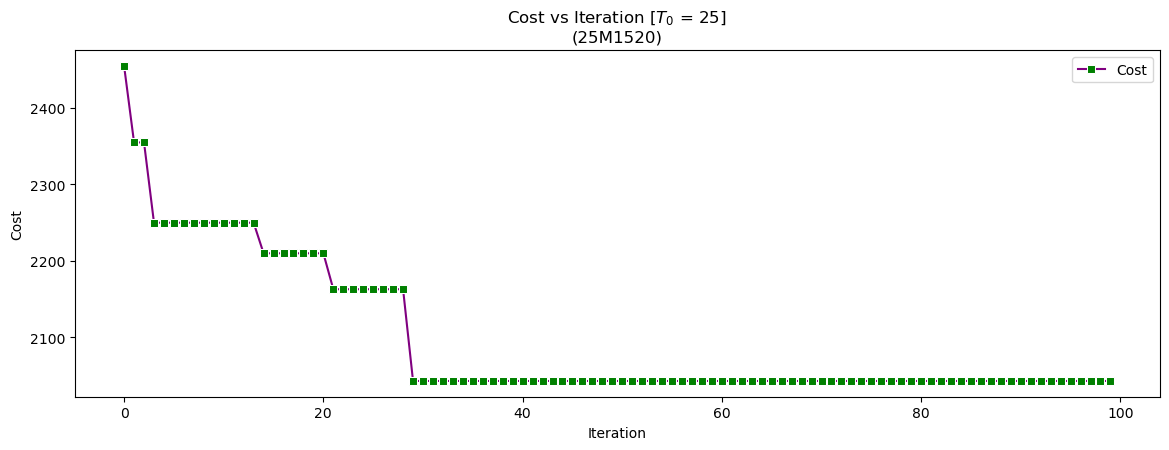

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 50

Forward Optimal tour:
5 → 8 → 11 → 4 → 3 → 9 → 2 → 6 → 1 → 10 → 7 → 5

Reverse Optimal tour:
5 → 7 → 10 → 1 → 6 → 2 → 9 → 3 → 4 → 11 → 8 → 5

Total cost: 1709


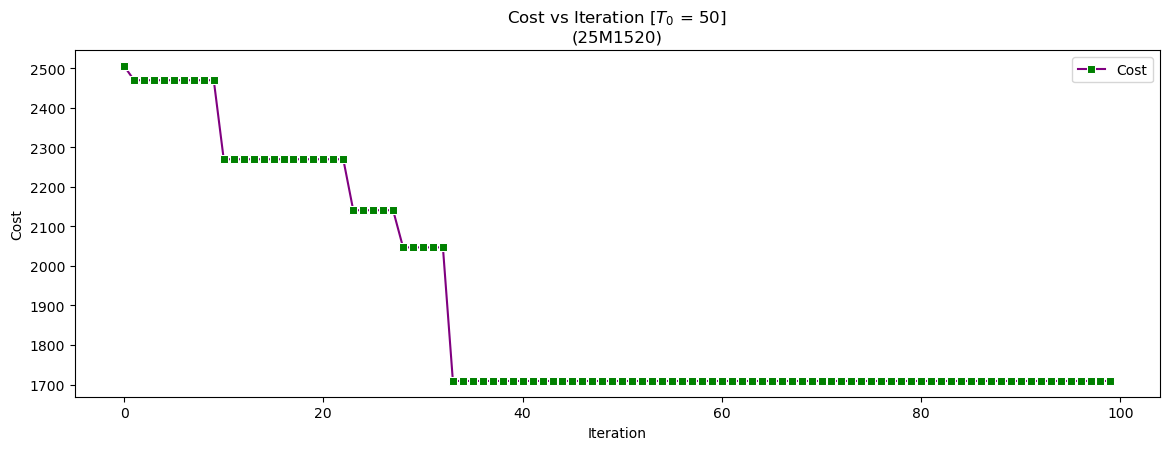

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 100

Forward Optimal tour:
1 → 7 → 3 → 4 → 11 → 6 → 2 → 9 → 10 → 5 → 8 → 1

Reverse Optimal tour:
1 → 8 → 5 → 10 → 9 → 2 → 6 → 11 → 4 → 3 → 7 → 1

Total cost: 2084


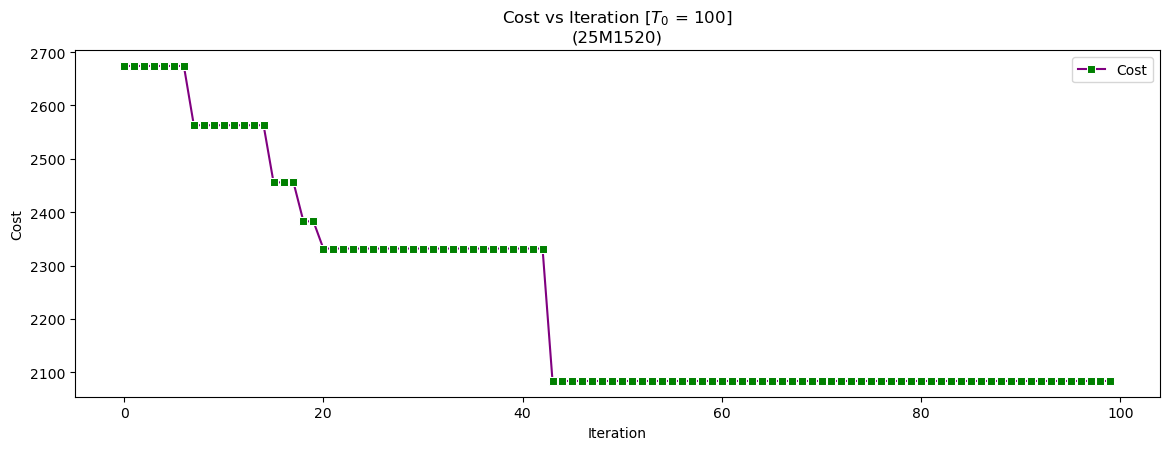

------------------------------------------------------------------------------------------------------------------------------------------------------


In [19]:
for T0 in [10, 25, 50, 100]:
    run_experiment(Adjacency_Matrix=tsp11, cooling_schedule=geometric_cooling, T0=T0)

# Question 9: 

### ***Alternative Cooling Schedule : Logarithmic Cooling***

In [20]:
def log_cooling(T0, alpha):
    return T0 / np.log(alpha+2)


Running with T0 = 1

Forward Optimal tour:
3 → 10 → 2 → 4 → 9 → 6 → 7 → 5 → 1 → 8 → 11 → 3

Reverse Optimal tour:
3 → 11 → 8 → 1 → 5 → 7 → 6 → 9 → 4 → 2 → 10 → 3

Total cost: 2600


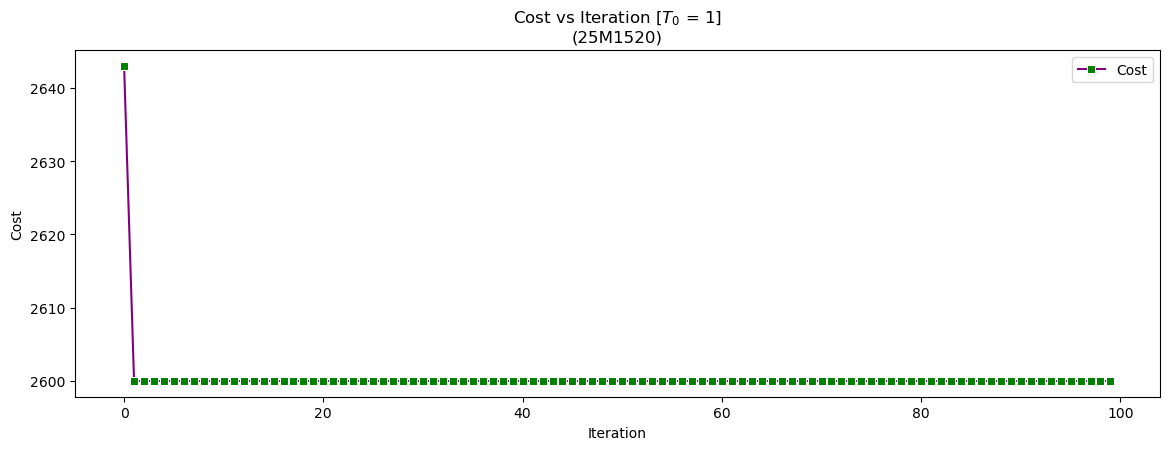

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 10

Forward Optimal tour:
10 → 3 → 11 → 5 → 1 → 9 → 2 → 8 → 6 → 4 → 7 → 10

Reverse Optimal tour:
10 → 7 → 4 → 6 → 8 → 2 → 9 → 1 → 5 → 11 → 3 → 10

Total cost: 2535


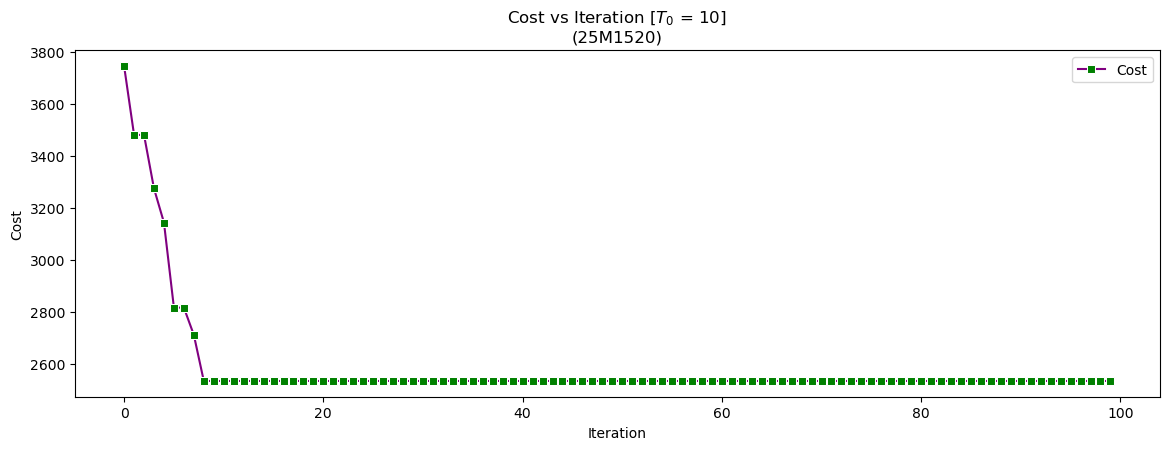

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 25

Forward Optimal tour:
2 → 8 → 5 → 10 → 11 → 4 → 6 → 1 → 9 → 3 → 7 → 2

Reverse Optimal tour:
2 → 7 → 3 → 9 → 1 → 6 → 4 → 11 → 10 → 5 → 8 → 2

Total cost: 1876


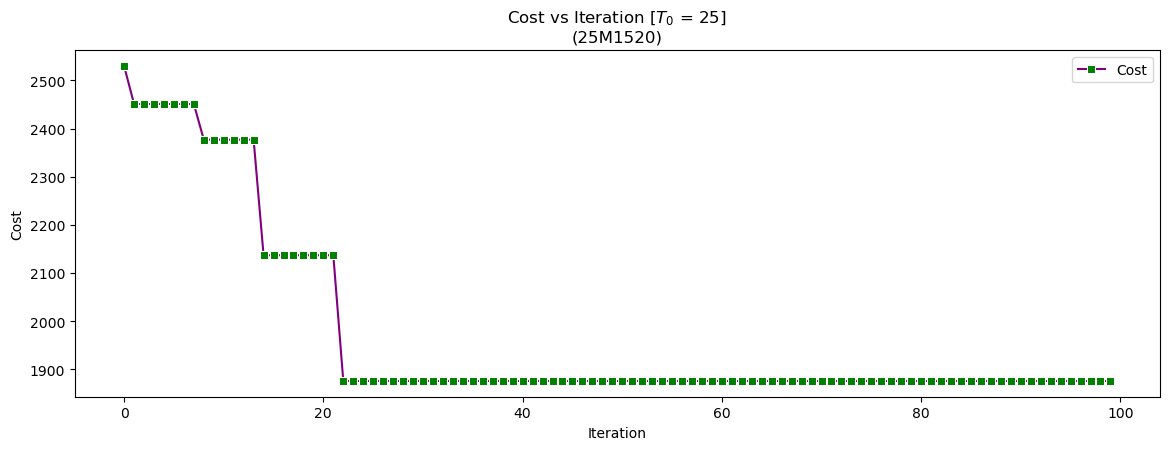

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 50

Forward Optimal tour:
8 → 7 → 10 → 3 → 6 → 11 → 4 → 5 → 1 → 9 → 2 → 8

Reverse Optimal tour:
8 → 2 → 9 → 1 → 5 → 4 → 11 → 6 → 3 → 10 → 7 → 8

Total cost: 2200


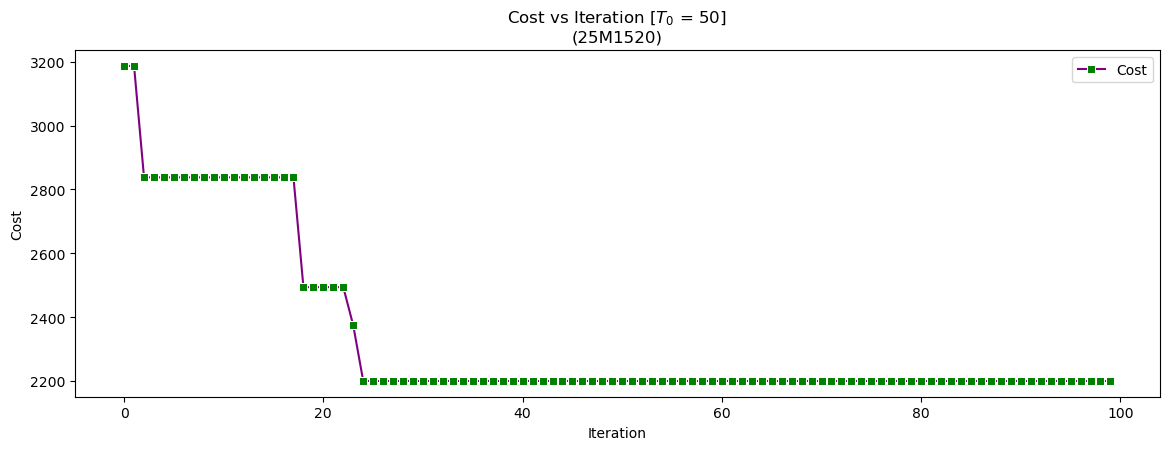

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 100

Forward Optimal tour:
9 → 1 → 10 → 5 → 8 → 2 → 4 → 11 → 6 → 7 → 3 → 9

Reverse Optimal tour:
9 → 3 → 7 → 6 → 11 → 4 → 2 → 8 → 5 → 10 → 1 → 9

Total cost: 1874


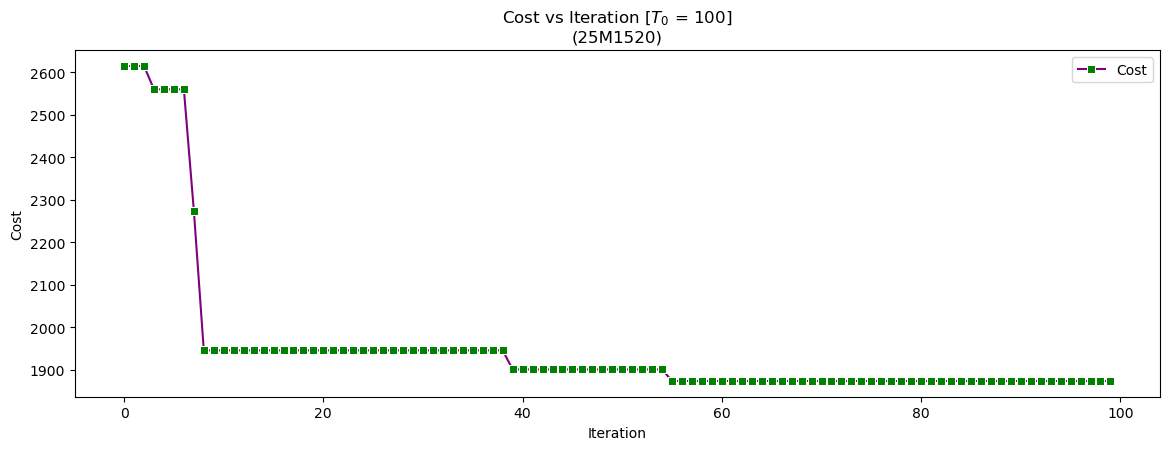

------------------------------------------------------------------------------------------------------------------------------------------------------


In [21]:
for T0 in [1, 10, 25, 50, 100]:
    run_experiment(Adjacency_Matrix=tsp11, cooling_schedule=log_cooling, T0=T0)

### ***Comments :***

* ***Cooling is slower*** compared to geometric cooling.

* Allows ***more exploration*** for longer time.

* Gives better solutions but ***increases computation time***.

* ***More stable*** convergence.

# Question 10: 

In [22]:
tsp48 = pd.read_csv("TSP48.csv", index_col=0)
tsp48.index = tsp48.index.str.replace("City_", "")
tsp48.columns = tsp48.columns.str.replace("City_", "")
tsp48

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
1,0,385,402,342,118,762,37,615,126,143,...,579,524,977,196,155,893,119,400,880,200
2,385,0,233,650,882,431,310,608,700,919,...,987,149,575,206,377,715,557,454,844,325
3,402,233,0,533,71,960,905,765,324,76,...,898,862,887,648,119,213,835,513,36,665
4,342,650,533,0,291,335,316,429,321,453,...,516,500,397,444,492,904,782,979,78,513
5,118,882,71,291,0,242,218,572,907,990,...,678,834,577,973,951,550,495,706,970,523
6,762,431,960,335,242,0,112,479,926,919,...,89,656,413,227,271,560,342,30,760,791
7,37,310,905,316,218,112,0,325,875,873,...,764,425,621,838,952,64,624,359,357,403
8,615,608,765,429,572,479,325,0,850,944,...,590,954,789,508,456,933,193,810,530,73
9,126,700,324,321,907,926,875,850,0,875,...,622,487,420,112,570,374,539,638,185,34
10,143,919,76,453,990,919,873,944,875,0,...,790,513,244,546,534,879,386,258,692,998


### ***Cooling Schedule : Geometric Cooling***


Running with T0 = 1

Forward Optimal tour:
41 → 46 → 3 → 30 → 44 → 21 → 38 → 10 → 42 → 6 → 45 → 29 → 39 → 16 → 23 → 36 → 1 → 15 → 12 → 33 → 4 → 40 → 20 → 28 → 27 → 43 → 48 → 8 → 14 → 24 → 9 → 37 → 11 → 32 → 13 → 35 → 19 → 7 → 34 → 25 → 18 → 26 → 2 → 17 → 5 → 31 → 22 → 47 → 41

Reverse Optimal tour:
41 → 47 → 22 → 31 → 5 → 17 → 2 → 26 → 18 → 25 → 34 → 7 → 19 → 35 → 13 → 32 → 11 → 37 → 9 → 24 → 14 → 8 → 48 → 43 → 27 → 28 → 20 → 40 → 4 → 33 → 12 → 15 → 1 → 36 → 23 → 16 → 39 → 29 → 45 → 6 → 42 → 10 → 38 → 21 → 44 → 30 → 3 → 46 → 41

Total cost: 16476


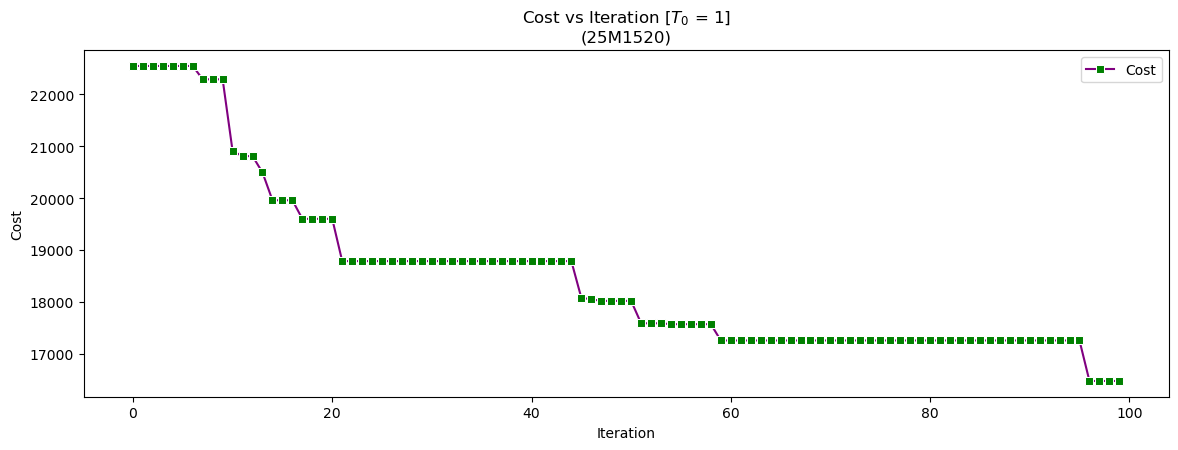

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 10

Forward Optimal tour:
11 → 40 → 7 → 8 → 4 → 1 → 5 → 44 → 20 → 6 → 27 → 25 → 48 → 19 → 31 → 42 → 35 → 9 → 37 → 17 → 32 → 39 → 24 → 34 → 2 → 15 → 13 → 46 → 12 → 33 → 10 → 41 → 36 → 21 → 3 → 28 → 38 → 43 → 18 → 47 → 22 → 26 → 14 → 23 → 45 → 16 → 29 → 30 → 11

Reverse Optimal tour:
11 → 30 → 29 → 16 → 45 → 23 → 14 → 26 → 22 → 47 → 18 → 43 → 38 → 28 → 3 → 21 → 36 → 41 → 10 → 33 → 12 → 46 → 13 → 15 → 2 → 34 → 24 → 39 → 32 → 17 → 37 → 9 → 35 → 42 → 31 → 19 → 48 → 25 → 27 → 6 → 20 → 44 → 5 → 1 → 4 → 8 → 7 → 40 → 11

Total cost: 17839


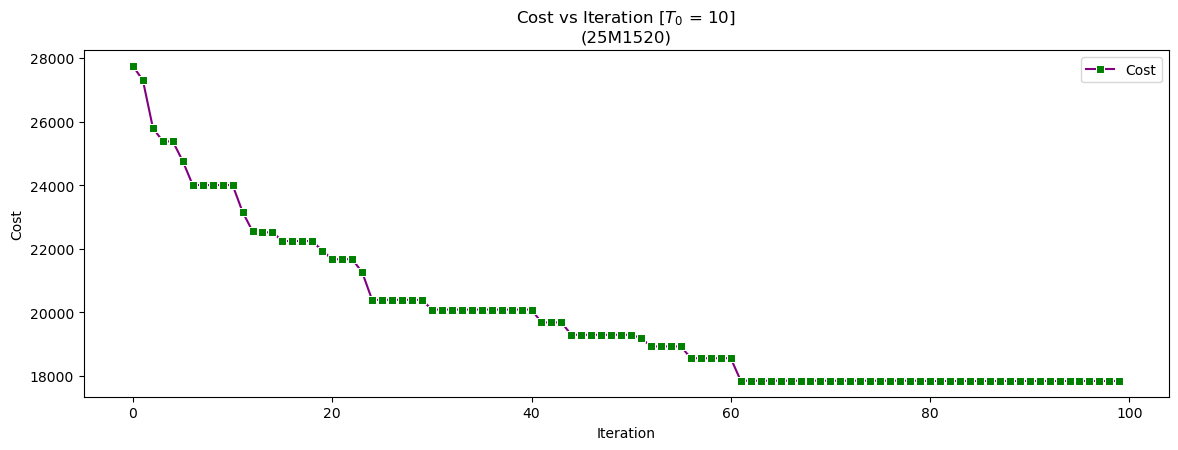

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 25

Forward Optimal tour:
40 → 47 → 43 → 17 → 2 → 13 → 24 → 28 → 21 → 4 → 39 → 11 → 32 → 35 → 41 → 45 → 46 → 12 → 7 → 33 → 36 → 14 → 6 → 22 → 19 → 3 → 44 → 20 → 23 → 37 → 18 → 26 → 27 → 8 → 34 → 48 → 31 → 10 → 38 → 42 → 1 → 15 → 9 → 16 → 25 → 5 → 30 → 29 → 40

Reverse Optimal tour:
40 → 29 → 30 → 5 → 25 → 16 → 9 → 15 → 1 → 42 → 38 → 10 → 31 → 48 → 34 → 8 → 27 → 26 → 18 → 37 → 23 → 20 → 44 → 3 → 19 → 22 → 6 → 14 → 36 → 33 → 7 → 12 → 46 → 45 → 41 → 35 → 32 → 11 → 39 → 4 → 21 → 28 → 24 → 13 → 2 → 17 → 43 → 47 → 40

Total cost: 18146


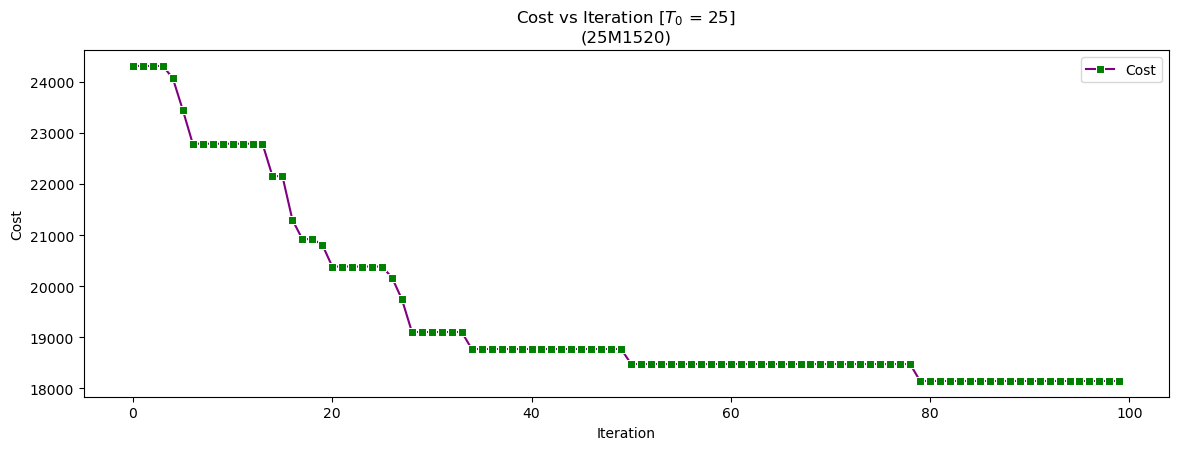

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 50

Forward Optimal tour:
42 → 45 → 14 → 38 → 16 → 28 → 12 → 23 → 8 → 29 → 20 → 36 → 40 → 26 → 21 → 39 → 19 → 44 → 41 → 6 → 47 → 35 → 10 → 1 → 5 → 27 → 7 → 24 → 43 → 46 → 15 → 11 → 4 → 32 → 31 → 48 → 33 → 22 → 18 → 9 → 3 → 25 → 30 → 13 → 17 → 2 → 34 → 37 → 42

Reverse Optimal tour:
42 → 37 → 34 → 2 → 17 → 13 → 30 → 25 → 3 → 9 → 18 → 22 → 33 → 48 → 31 → 32 → 4 → 11 → 15 → 46 → 43 → 24 → 7 → 27 → 5 → 1 → 10 → 35 → 47 → 6 → 41 → 44 → 19 → 39 → 21 → 26 → 40 → 36 → 20 → 29 → 8 → 23 → 12 → 28 → 16 → 38 → 14 → 45 → 42

Total cost: 16258


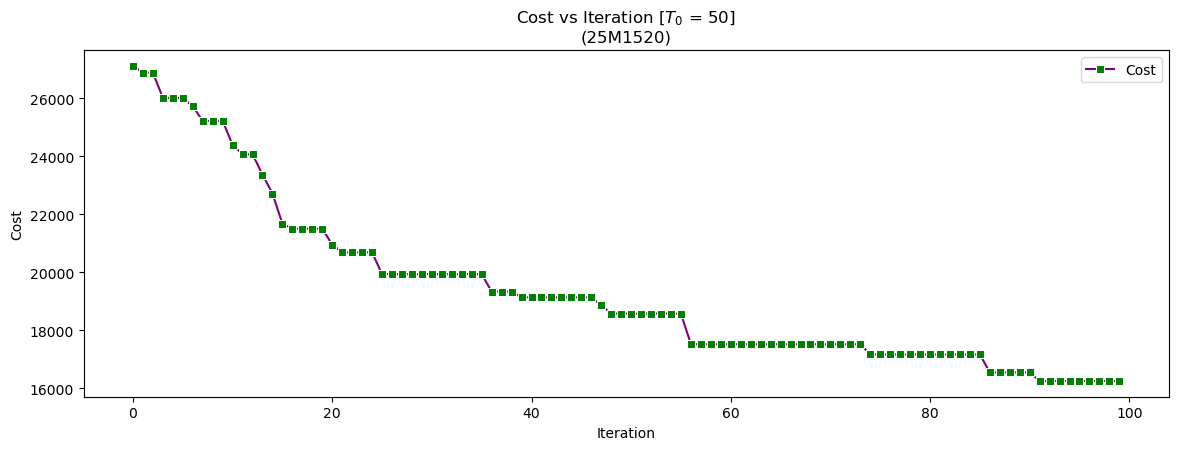

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 100

Forward Optimal tour:
16 → 9 → 15 → 28 → 2 → 48 → 1 → 12 → 19 → 37 → 10 → 24 → 23 → 47 → 40 → 26 → 39 → 32 → 27 → 38 → 5 → 30 → 14 → 44 → 20 → 3 → 43 → 25 → 17 → 45 → 34 → 18 → 46 → 8 → 4 → 22 → 11 → 36 → 7 → 33 → 21 → 29 → 42 → 41 → 31 → 13 → 6 → 35 → 16

Reverse Optimal tour:
16 → 35 → 6 → 13 → 31 → 41 → 42 → 29 → 21 → 33 → 7 → 36 → 11 → 22 → 4 → 8 → 46 → 18 → 34 → 45 → 17 → 25 → 43 → 3 → 20 → 44 → 14 → 30 → 5 → 38 → 27 → 32 → 39 → 26 → 40 → 47 → 23 → 24 → 10 → 37 → 19 → 12 → 1 → 48 → 2 → 28 → 15 → 9 → 16

Total cost: 18278


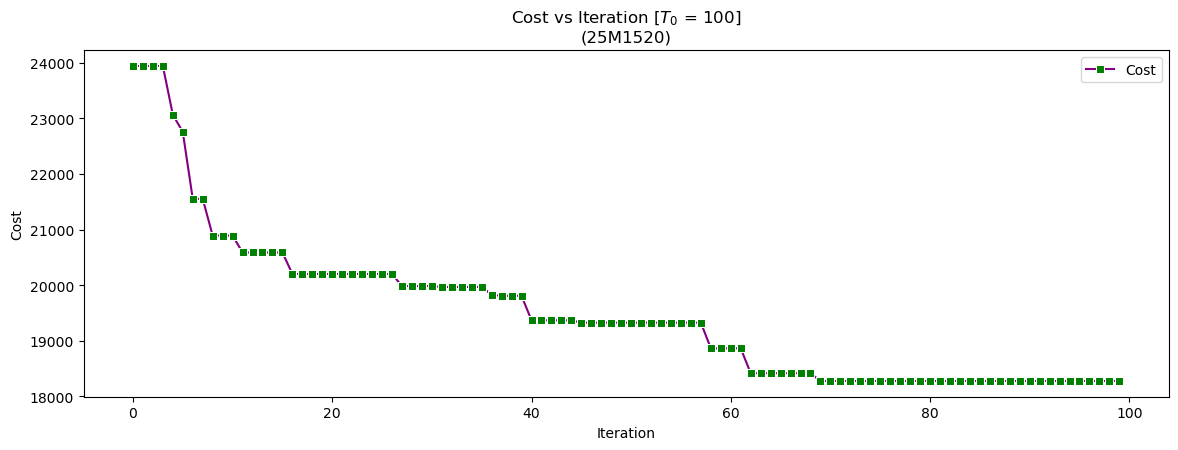

------------------------------------------------------------------------------------------------------------------------------------------------------


In [23]:
for T0 in [1, 10, 25, 50, 100]:
    run_experiment(Adjacency_Matrix=tsp48, cooling_schedule=geometric_cooling, T0=T0)

### ***Cooling Schedule : Logarithmic Cooling***


Running with T0 = 1

Forward Optimal tour:
7 → 31 → 46 → 20 → 4 → 38 → 26 → 18 → 32 → 15 → 8 → 47 → 40 → 39 → 17 → 9 → 35 → 1 → 12 → 44 → 37 → 45 → 14 → 13 → 3 → 25 → 10 → 30 → 34 → 24 → 42 → 28 → 33 → 43 → 41 → 29 → 36 → 48 → 2 → 16 → 27 → 22 → 19 → 21 → 5 → 11 → 23 → 6 → 7

Reverse Optimal tour:
7 → 6 → 23 → 11 → 5 → 21 → 19 → 22 → 27 → 16 → 2 → 48 → 36 → 29 → 41 → 43 → 33 → 28 → 42 → 24 → 34 → 30 → 10 → 25 → 3 → 13 → 14 → 45 → 37 → 44 → 12 → 1 → 35 → 9 → 17 → 39 → 40 → 47 → 8 → 15 → 32 → 18 → 26 → 38 → 4 → 20 → 46 → 31 → 7

Total cost: 17461


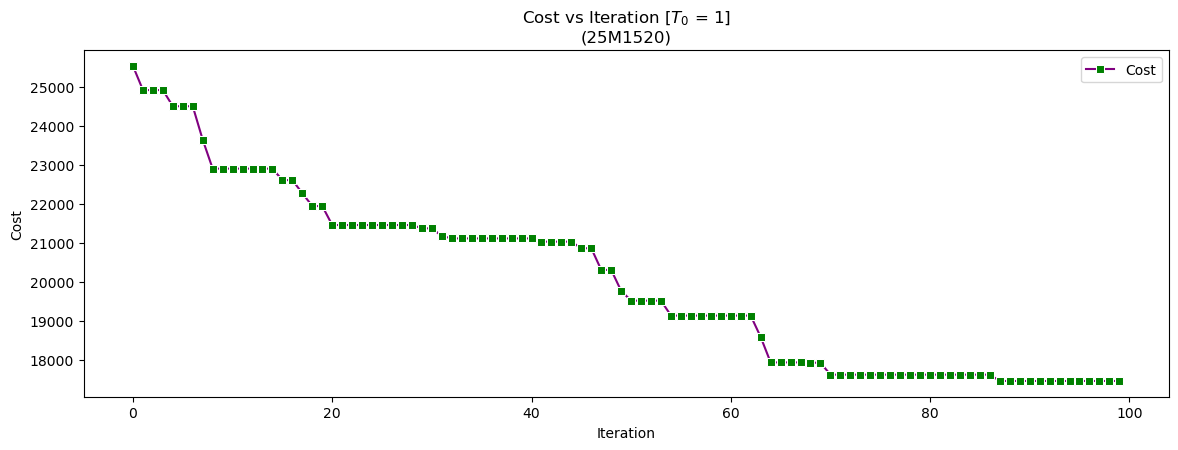

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 10

Forward Optimal tour:
41 → 44 → 33 → 19 → 29 → 47 → 27 → 12 → 13 → 48 → 22 → 39 → 26 → 40 → 6 → 11 → 2 → 46 → 30 → 45 → 8 → 43 → 1 → 9 → 35 → 38 → 20 → 23 → 15 → 10 → 32 → 28 → 7 → 25 → 18 → 16 → 4 → 42 → 17 → 21 → 3 → 37 → 24 → 36 → 31 → 5 → 34 → 14 → 41

Reverse Optimal tour:
41 → 14 → 34 → 5 → 31 → 36 → 24 → 37 → 3 → 21 → 17 → 42 → 4 → 16 → 18 → 25 → 7 → 28 → 32 → 10 → 15 → 23 → 20 → 38 → 35 → 9 → 1 → 43 → 8 → 45 → 30 → 46 → 2 → 11 → 6 → 40 → 26 → 39 → 22 → 48 → 13 → 12 → 27 → 47 → 29 → 19 → 33 → 44 → 41

Total cost: 17026


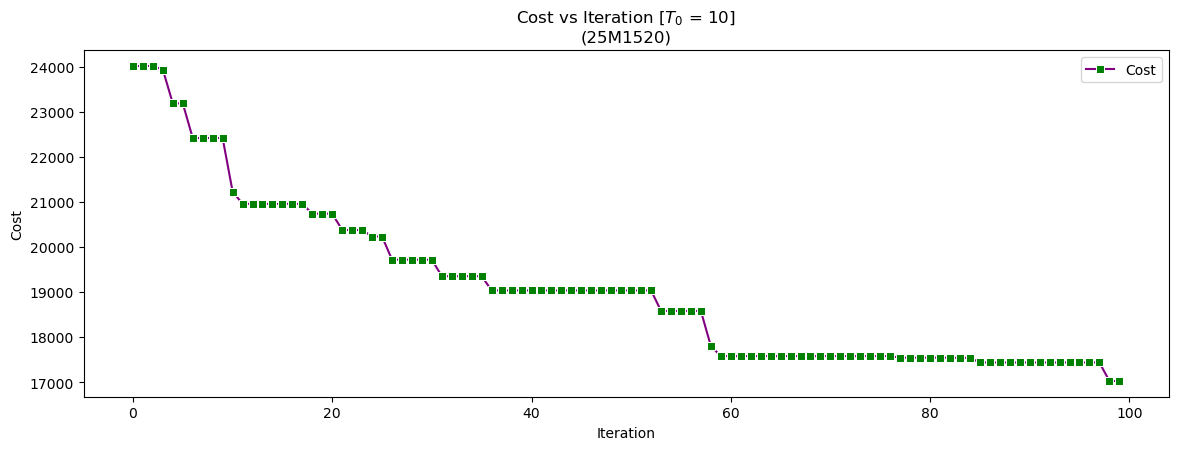

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 25

Forward Optimal tour:
32 → 41 → 4 → 21 → 39 → 13 → 17 → 33 → 24 → 14 → 48 → 44 → 30 → 31 → 36 → 19 → 10 → 3 → 43 → 6 → 22 → 18 → 9 → 16 → 42 → 38 → 15 → 1 → 35 → 8 → 2 → 34 → 7 → 5 → 25 → 45 → 11 → 29 → 47 → 12 → 23 → 46 → 40 → 37 → 27 → 26 → 20 → 28 → 32

Reverse Optimal tour:
32 → 28 → 20 → 26 → 27 → 37 → 40 → 46 → 23 → 12 → 47 → 29 → 11 → 45 → 25 → 5 → 7 → 34 → 2 → 8 → 35 → 1 → 15 → 38 → 42 → 16 → 9 → 18 → 22 → 6 → 43 → 3 → 10 → 19 → 36 → 31 → 30 → 44 → 48 → 14 → 24 → 33 → 17 → 13 → 39 → 21 → 4 → 41 → 32

Total cost: 15532


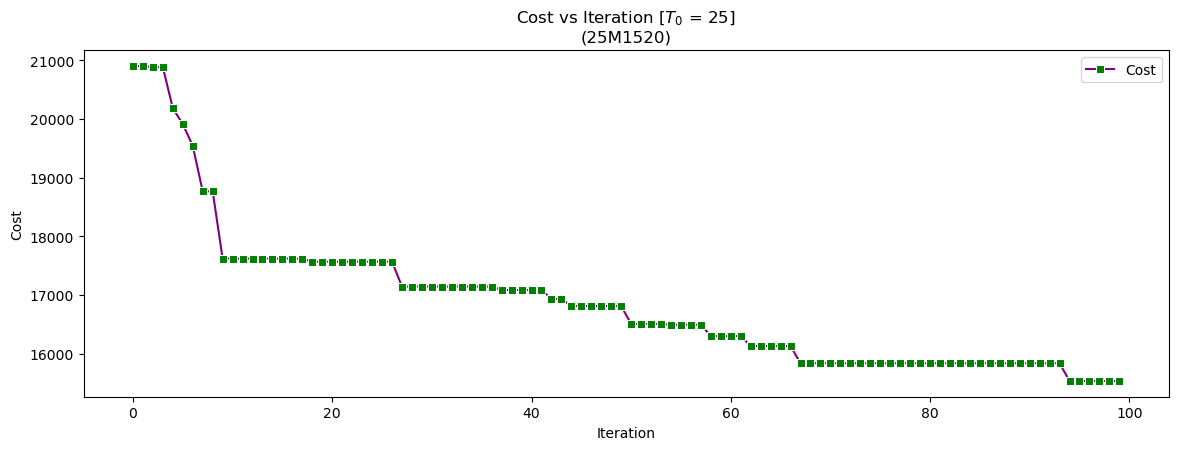

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 50

Forward Optimal tour:
41 → 40 → 15 → 1 → 18 → 33 → 48 → 19 → 29 → 20 → 24 → 9 → 16 → 13 → 27 → 11 → 45 → 36 → 2 → 3 → 14 → 30 → 46 → 8 → 43 → 21 → 38 → 7 → 5 → 31 → 44 → 39 → 26 → 22 → 10 → 35 → 32 → 6 → 37 → 42 → 23 → 25 → 47 → 4 → 34 → 12 → 28 → 17 → 41

Reverse Optimal tour:
41 → 17 → 28 → 12 → 34 → 4 → 47 → 25 → 23 → 42 → 37 → 6 → 32 → 35 → 10 → 22 → 26 → 39 → 44 → 31 → 5 → 7 → 38 → 21 → 43 → 8 → 46 → 30 → 14 → 3 → 2 → 36 → 45 → 11 → 27 → 13 → 16 → 9 → 24 → 20 → 29 → 19 → 48 → 33 → 18 → 1 → 15 → 40 → 41

Total cost: 15323


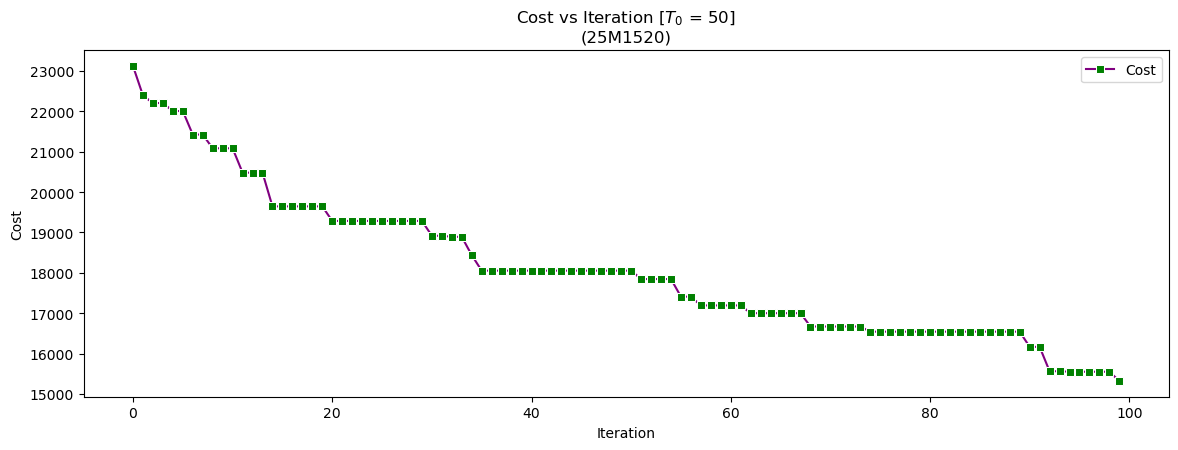

------------------------------------------------------------------------------------------------------------------------------------------------------

Running with T0 = 100

Forward Optimal tour:
25 → 32 → 20 → 7 → 27 → 10 → 14 → 21 → 26 → 35 → 2 → 15 → 45 → 31 → 41 → 4 → 30 → 37 → 47 → 43 → 12 → 28 → 17 → 48 → 33 → 38 → 40 → 1 → 24 → 13 → 46 → 3 → 9 → 19 → 22 → 6 → 34 → 44 → 29 → 36 → 23 → 42 → 8 → 16 → 39 → 11 → 5 → 18 → 25

Reverse Optimal tour:
25 → 18 → 5 → 11 → 39 → 16 → 8 → 42 → 23 → 36 → 29 → 44 → 34 → 6 → 22 → 19 → 9 → 3 → 46 → 13 → 24 → 1 → 40 → 38 → 33 → 48 → 17 → 28 → 12 → 43 → 47 → 37 → 30 → 4 → 41 → 31 → 45 → 15 → 2 → 35 → 26 → 21 → 14 → 10 → 27 → 7 → 20 → 32 → 25

Total cost: 15566


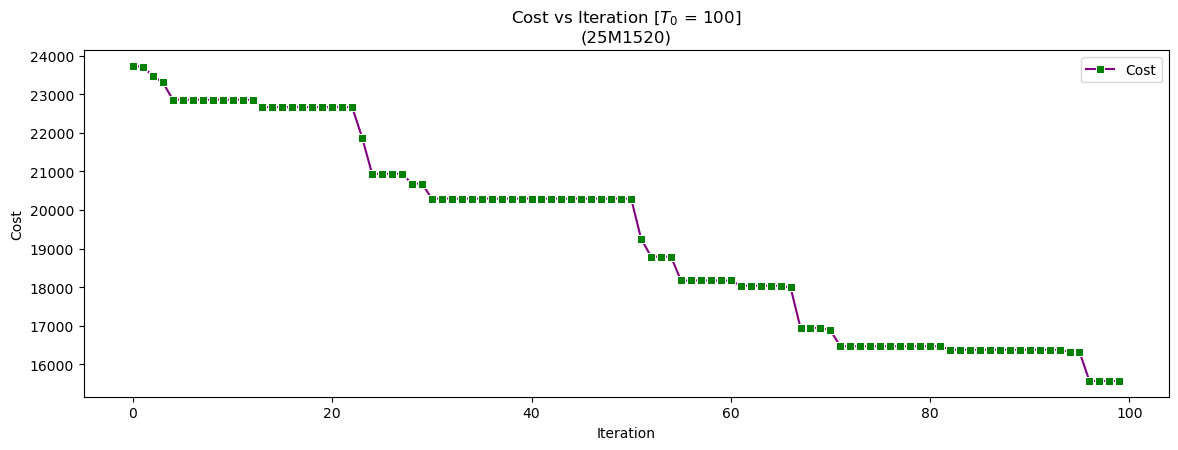

------------------------------------------------------------------------------------------------------------------------------------------------------


In [24]:
for T0 in [1, 10, 25, 50, 100]:
    run_experiment(Adjacency_Matrix=tsp48, cooling_schedule=log_cooling, T0=T0)

### ***Comments :***

* Problem becomes ***more complex*** due to ***larger search space***.

* ***Convergence is slower*** and ***requires more iterations***.

* Solution quality depends heavily on parameter tuning.

* Simulated annealing still finds a good approximate solution efficiently.

* Multiple runs may give different solutions.

---